# QuRad vs Python PyRadiomics Comparison

This notebook compares radiomics features extracted by:
1. **QuRad** - QuPath Groovy extension
2. **PyRadiomics** - Python package

## Setup

### Loading Example Data into QuPath

1. **Open QuPath**
2. **File > Open** and select: `QuRad/example_data/image.tif`
3. **Run cell detection** (e.g., StarDist, Cellpose, or QuPath's built-in detector)
4. **Run QuRad script**: `Automate > Script editor > Open > QuPath_Radiomics_v2.groovy`
5. **Click Run** - This generates a CSV file in `/radiomics/`

The example data includes:
- `image.tif` - Grayscale H&E image
- `labels.tif` - Labeled mask (each cell has unique integer value 1, 2, 3...)
- `cell_detections.geojson`- Cell detections to be imported in QuPath

## Workflow
1. Load example image and labels
2. Run Python pyradiomics on the image + labeled mask
3. Compare feature values with QuRad results

## Loading

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
import os
from pathlib import Path
import SimpleITK as sitk
from radiomics import featureextractor
import warnings
warnings.filterwarnings('ignore')

In [2]:
NOTEBOOK_DIR = Path(os.getcwd())  # Current working directory
BASE_DIR = Path("/Users/tamara/Desktop/PyRadiomics")

EXAMPLE_DATA_DIR = BASE_DIR / "QuRad" / "example_data"
QUPATH_RADIOMICS_DIR = BASE_DIR / "Qupath" / "radiomics"

# Example data files
IMAGE_PATH = EXAMPLE_DATA_DIR / "ILR192-11-17-36-45_8367_10109_z0_t0.tif"
LABELS_PATH = EXAMPLE_DATA_DIR / "ILR192-11-17-36-45_8367_10109_z0_t0_cp_masks.tif"

QURAD_CSV_DIR = QUPATH_RADIOMICS_DIR

print(f"Example data directory: {EXAMPLE_DATA_DIR}")
print(f"Image: {IMAGE_PATH}")
print(f"Labels: {LABELS_PATH}")
print(f"QuRad results directory: {QURAD_CSV_DIR}")

Example data directory: /Users/tamara/Desktop/PyRadiomics/QuRad/example_data
Image: /Users/tamara/Desktop/PyRadiomics/QuRad/example_data/ILR192-11-17-36-45_8367_10109_z0_t0.tif
Labels: /Users/tamara/Desktop/PyRadiomics/QuRad/example_data/ILR192-11-17-36-45_8367_10109_z0_t0_cp_masks.tif
QuRad results directory: /Users/tamara/Desktop/PyRadiomics/Qupath/radiomics


In [3]:
# Load example image and labels
if not IMAGE_PATH.exists() or not LABELS_PATH.exists():
    print("✗ Example data not found!")
    print(f"  Expected:")
    print(f"    Image: {IMAGE_PATH}")
    print(f"    Labels: {LABELS_PATH}")
    print(f"\n  Please ensure the example data files exist.")
else:
    # Load and decode label image
    label_img = np.array(Image.open(LABELS_PATH))
    print(f"✓ Loaded label image")
    print(f"  Shape: {label_img.shape}")
    print(f"  Dtype: {label_img.dtype}")
    
    # Decode RGB-encoded labels to single integer
    if len(label_img.shape) == 3:  # RGB image
        labels = (label_img[:,:,0].astype(np.int32) * 65536 + 
                  label_img[:,:,1].astype(np.int32) * 256 + 
                  label_img[:,:,2].astype(np.int32))
    else:
        labels = label_img.astype(np.int32)
    
    unique_labels = np.unique(labels)
    # Exclude background (label 0)
    cell_labels = unique_labels[unique_labels > 0]
    print(f"\n  Unique labels (including background): {len(unique_labels)}")
    print(f"  Cell labels: {len(cell_labels)}")
    print(f"  Label range: {cell_labels.min()} to {cell_labels.max()}")
    
    # Load grayscale image
    gray_img = np.array(Image.open(IMAGE_PATH))
    print(f"\n✓ Loaded grayscale image")
    print(f"  Shape: {gray_img.shape}")
    print(f"  Dtype: {gray_img.dtype}")

✓ Loaded label image
  Shape: (1074, 1116)
  Dtype: uint16

  Unique labels (including background): 498
  Cell labels: 497
  Label range: 1 to 497

✓ Loaded grayscale image
  Shape: (1074, 1116)
  Dtype: float32


## Exporting mask for QuPath

Save labels.tif as cell_detections.geojson

In [4]:
import json
from skimage import measure
from shapely.geometry import Polygon, MultiPolygon, mapping

OUTPUT_GEOJSON = BASE_DIR / "QuRad" / "example_data" / "cell_detections.geojson"

features = []

for label_id in cell_labels:
    binary = (labels == label_id).astype(np.uint8)

    # Extract contours at pixel-accurate boundary
    contours = measure.find_contours(binary, level=0.5)

    polygons = []
    for contour in contours:
        # contour is (row, col) → convert to (x, y)
        poly = Polygon(contour[:, ::-1])

        # Filter tiny artifacts
        if poly.area >= 5:
            polygons.append(poly)

    if not polygons:
        continue

    geom = polygons[0] if len(polygons) == 1 else MultiPolygon(polygons)

    features.append({
        "type": "Feature",
        "geometry": mapping(geom),
        "properties": {
            "label_id": int(label_id),
            "object_type": "detection"
        }
    })

geojson = {
    "type": "FeatureCollection",
    "features": features
}

with open(OUTPUT_GEOJSON, "w") as f:
    json.dump(geojson, f)

print(f"✓ Exported {len(features)} cell detections")
print(f"→ {OUTPUT_GEOJSON}")


✓ Exported 497 cell detections
→ /Users/tamara/Desktop/PyRadiomics/QuRad/example_data/cell_detections.geojson


## Configure PyRadiomics

Set up the feature extractor with settings matching QuRad.

In [5]:
# Configure pyradiomics to match QuRad settings
settings = {
    'binWidth': 25,  # Same as QuRad
    'resampledPixelSpacing': None,  # No resampling
    'interpolator': sitk.sitkBSpline,
    'force2D': True,
    'force2Ddimension': 0,
    'normalize': False,
    'normalizeScale': 1,
    'removeOutliers': None,
    'voxelArrayShift': 0,
}

# Initialize the feature extractor
extractor = featureextractor.RadiomicsFeatureExtractor(**settings)

# Enable feature classes matching QuRad
extractor.disableAllFeatures()
extractor.enableFeatureClassByName('firstorder')
extractor.enableFeatureClassByName('shape2D')
extractor.enableFeatureClassByName('glcm')
extractor.enableFeatureClassByName('glrlm')
extractor.enableFeatureClassByName('glszm')
extractor.enableFeatureClassByName('ngtdm')
extractor.enableFeatureClassByName('gldm')

print("PyRadiomics Feature Extractor configured")
print(f"\nEnabled feature classes:")
for cls in extractor.enabledFeatures.keys():
    print(f"  - {cls}")

PyRadiomics Feature Extractor configured

Enabled feature classes:
  - firstorder
  - shape2D
  - glcm
  - glrlm
  - glszm
  - ngtdm
  - gldm


## Step 3: Extract PyRadiomics Features

Extract features for each labeled cell in the mask.

In [6]:
def extract_features_for_label(image_sitk, labels_sitk, label_value):
    """Extract pyradiomics features for a single label."""
    try:
        # Create binary mask for this label
        mask = sitk.Cast(labels_sitk == label_value, sitk.sitkInt32)
        
        # Check if mask has any pixels
        mask_array = sitk.GetArrayFromImage(mask)
        if mask_array.sum() == 0:
            return None
        
        # Calculate centroid from mask for spatial matching
        y_coords, x_coords = np.where(mask_array[0] > 0)  # Get coordinates (z, y, x) -> [0] for first slice
        if len(y_coords) == 0:
            return None
        centroid_y = float(np.mean(y_coords))
        centroid_x = float(np.mean(x_coords))
        
        # Extract features
        result = extractor.execute(image_sitk, mask, label=1)
        
        # Filter to only radiomics features (exclude diagnostics)
        features = {k: float(v) for k, v in result.items() 
                   if not k.startswith('diagnostics_')}
        
        # Add centroid coordinates for spatial matching with QuRad
        features['CentroidX'] = centroid_x
        features['CentroidY'] = centroid_y
        
        return features
    except Exception as e:
        return None

# Convert numpy arrays to SimpleITK images
if 'gray_img' in dir() and 'labels' in dir():
    # Ensure grayscale is 2D
    if len(gray_img.shape) == 3:
        gray_2d = gray_img[:,:,0] if gray_img.shape[2] > 1 else gray_img.squeeze()
    else:
        gray_2d = gray_img
    
    # Add a dimension for SimpleITK (expects 3D for force2D)
    gray_3d = gray_2d[np.newaxis, :, :].astype(np.float32)
    labels_3d = labels[np.newaxis, :, :].astype(np.int32)
    
    image_sitk = sitk.GetImageFromArray(gray_3d)
    labels_sitk = sitk.GetImageFromArray(labels_3d)
    
    print(f"Image shape for PyRadiomics: {sitk.GetArrayFromImage(image_sitk).shape}")
    print(f"Labels shape for PyRadiomics: {sitk.GetArrayFromImage(labels_sitk).shape}")

Image shape for PyRadiomics: (1, 1074, 1116)
Labels shape for PyRadiomics: (1, 1074, 1116)


In [7]:
# Extract features for all labeled cells
pyrad_results = []

if 'gray_img' in dir() and 'labels' in dir():
    # Convert numpy arrays to SimpleITK images
    # Ensure grayscale is 2D
    if len(gray_img.shape) == 3:
        gray_2d = gray_img[:,:,0] if gray_img.shape[2] > 1 else gray_img.squeeze()
    else:
        gray_2d = gray_img
    
    # Add a dimension for SimpleITK (expects 3D for force2D)
    gray_3d = gray_2d[np.newaxis, :, :].astype(np.float32)
    labels_3d = labels[np.newaxis, :, :].astype(np.int32)
    
    image_sitk = sitk.GetImageFromArray(gray_3d)
    labels_sitk = sitk.GetImageFromArray(labels_3d)
    
    print(f"Image shape for PyRadiomics: {sitk.GetArrayFromImage(image_sitk).shape}")
    print(f"Labels shape for PyRadiomics: {sitk.GetArrayFromImage(labels_sitk).shape}")
    
    # Get all cell labels (exclude background)
    cell_labels = np.unique(labels)
    cell_labels = cell_labels[cell_labels > 0]
    total_cells = len(cell_labels)
    
    # Limit to first N cells for testing (remove or increase for full extraction)
    max_cells = min(1000, total_cells)  # Set to total_cells for all
    
    print(f"\nExtracting PyRadiomics features for {max_cells} cells...\n")
    
    for idx, label_value in enumerate(cell_labels[:max_cells]):
        features = extract_features_for_label(image_sitk, labels_sitk, label_value)
        
        if features:
            features['label'] = int(label_value)
            # Use label as cell_id since we don't have QuPath IDs
            features['cell_id'] = f"label_{label_value}"
            pyrad_results.append(features)
        
        # Progress update
        if (idx + 1) % 20 == 0:
            print(f"  Processed {idx + 1}/{max_cells} cells...")
    
    print(f"\n✓ Extracted features for {len(pyrad_results)} cells")
else:
    print("Please run previous cells to load the example data.")

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


Image shape for PyRadiomics: (1, 1074, 1116)
Labels shape for PyRadiomics: (1, 1074, 1116)

Extracting PyRadiomics features for 497 cells...



GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

  Processed 20/497 cells...


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

...

  Processed 460/497 cells...


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

  Processed 480/497 cells...


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera


✓ Extracted features for 497 cells


In [8]:
# Create DataFrame from PyRadiomics results
if pyrad_results:
    pyrad_df = pd.DataFrame(pyrad_results)
    print(f"PyRadiomics DataFrame shape: {pyrad_df.shape}")
    print(f"\nFeature classes extracted:")
    
    # Count features by class
    feature_counts = {}
    for col in pyrad_df.columns:
        if '_' in col and col not in ['label', 'cell_id']:
            prefix = col.split('_')[1]  # original_firstorder_X -> firstorder
            feature_counts[prefix] = feature_counts.get(prefix, 0) + 1
    
    for cls, count in sorted(feature_counts.items()):
        print(f"  {cls}: {count} features")
    
    print(f"\nTotal features: {sum(feature_counts.values())}")
    display(pyrad_df.head())

PyRadiomics DataFrame shape: (497, 106)

Feature classes extracted:
  firstorder: 18 features
  glcm: 24 features
  gldm: 14 features
  glrlm: 16 features
  glszm: 16 features
  ngtdm: 5 features
  shape2D: 9 features

Total features: 102


,original_shape2D_Elongation,original_shape2D_MajorAxisLength,original_shape2D_MaximumDiameter,original_shape2D_MeshSurface,original_shape2D_MinorAxisLength,original_shape2D_Perimeter,original_shape2D_PerimeterSurfaceRatio,original_shape2D_PixelSurface,original_shape2D_Sphericity,original_firstorder_10Percentile,...,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,CentroidX,CentroidY,label,cell_id
0,0.579884,12.750878,13.000000,72.5,7.394027,33.556349,0.462846,73.0,0.899496,170.2,...,98.698630,5.909912,0.270453,0.126665,1.050256,0.034517,145.876712,3.150685,1,label_1
1,0.769623,12.557286,12.649111,93.5,9.664374,38.384776,0.410532,94.0,0.893001,160.0,...,168.563830,1.396894,0.133508,0.184880,2.622304,0.033908,648.734043,4.670213,2,label_2
2,0.491717,17.368871,17.262677,114.5,8.540569,44.384776,0.387640,115.0,0.854621,170.4,...,139.765217,7.955802,0.313739,0.103713,0.840103,0.026774,691.330435,4.086957,3,label_3
3,0.549670,22.253744,21.840330,200.5,12.232212,59.213203,0.295328,201.0,0.847703,189.0,...,274.447761,4.443469,0.170735,0.084029,0.819830,0.015495,990.840796,8.527363,4,label_4
4,0.828106,15.533688,16.401219,155.5,12.863533,47.798990,0.307389,156.0,0.924808,172.5,...,234.916667,1.451517,0.111717,0.156652,2.408512,0.020004,1038.487179,5.993590,5,label_5


## Step 4: Load QuRad Results and Extract Centroids from GeoJSON

We'll use the geojson file to extract centroids for each cell, which will help us match cells between QuRad and PyRadiomics.

In [9]:
# Load geojson to extract centroids for matching
geojson_path = EXAMPLE_DATA_DIR / "cell_detections.geojson"
geojson_centroids = {}

if geojson_path.exists():
    with open(geojson_path, 'r') as f:
        geojson_data = json.load(f)
    
    for feature in geojson_data.get('features', []):
        label_id = feature.get('properties', {}).get('label_id')
        if label_id is not None:
            geom = feature.get('geometry', {})
            if geom.get('type') == 'Polygon':
                coords = geom.get('coordinates', [])[0]  # Exterior ring
            elif geom.get('type') == 'MultiPolygon':
                # Get largest polygon
                polygons = geom.get('coordinates', [])
                coords = max(polygons, key=lambda p: len(p[0]))[0]
            else:
                continue
            
            # Calculate centroid
            if coords:
                x_coords = [c[0] for c in coords]
                y_coords = [c[1] for c in coords]
                centroid_x = np.mean(x_coords)
                centroid_y = np.mean(y_coords)
                geojson_centroids[label_id] = {'CentroidX': centroid_x, 'CentroidY': centroid_y}
    
    print(f"✓ Loaded {len(geojson_centroids)} centroids from geojson")
else:
    print(f"⚠️  GeoJSON not found: {geojson_path}")

# Find the most recent QuRad CSV
radiomics_dir = QUPATH_RADIOMICS_DIR
qurad_files = sorted(radiomics_dir.glob("*.csv"), reverse=True)

if qurad_files:
    qurad_csv = qurad_files[0]
    print(f"\nLoading QuRad results from: {qurad_csv.name}")
    
    qurad_df = pd.read_csv(qurad_csv)
    print(f"QuRad DataFrame shape: {qurad_df.shape}")
    
    # Try to add centroids from geojson if we can match by label_id
    # First, check if QuPath exported any label information
    # If not, we'll need to match by spatial position
    
    # Count features by class
    print(f"\nFeature classes:")
    feature_counts = {}
    for col in qurad_df.columns:
        if '_' in col and col not in ['ObjectID', 'ObjectType', 'Classification']:
            prefix = col.split('_')[0]
            feature_counts[prefix] = feature_counts.get(prefix, 0) + 1
    
    for cls, count in sorted(feature_counts.items()):
        print(f"  {cls}: {count} features")
    
    # Check for image loading issue
    if 'firstorder_Mean' in qurad_df.columns:
        unique_means = qurad_df['firstorder_Mean'].unique()
        if len(unique_means) == 1 and unique_means[0] == 255.0:
            print(f"\n⚠️  WARNING: All firstorder_Mean values are 255.0!")
            print(f"   This suggests QuPath is not reading the image correctly.")
            print(f"   Possible causes:")
            print(f"   - Wrong image channel selected")
            print(f"   - Image not loaded properly in QuPath")
            print(f"   - Image is being read as a mask instead of intensity image")
    
    display(qurad_df.head())
else:
    print("No QuRad results found. Run QuPath_Radiomics_v2.groovy first.")

✓ Loaded 497 centroids from geojson

Loading QuRad results from: ILR192_11_17_36_45_8367_10109_z0_t0_tif_radiomics_20251216_010835.csv
QuRad DataFrame shape: (497, 123)

Feature classes:
  firstorder: 19 features
  glcm: 23 features
  gldm: 15 features
  glrlm: 16 features
  glszm: 16 features
  ngtdm: 5 features
  shape: 16 features
  shape2D: 10 features

⚠️  WARNING: All firstorder_Mean values are 255.0!
   This suggests QuPath is not reading the image correctly.
   Possible causes:
   - Wrong image channel selected
   - Image not loaded properly in QuPath
   - Image is being read as a mask instead of intensity image


,Classification,ObjectID,ObjectType,firstorder_10Percentile,firstorder_90Percentile,firstorder_Energy,firstorder_Entropy,firstorder_InterquartileRange,firstorder_Kurtosis,firstorder_Maximum,...,shape_Maximum2DDiameterRow,shape_Maximum2DDiameterSlice,shape_Maximum3DDiameter,shape_MeshVolume,shape_MinorAxisLength,shape_SphericalDisproportion,shape_Sphericity,shape_SurfaceArea,shape_SurfaceVolumeRatio,shape_VoxelVolume
0,Unclassified,7d8305aa-d147-49a8-93e6-c111cd6c93f6,Detection,255.0,255.0,4746825.0,0.0,0.0,0.0,255.0,...,7.5,14.150972,14.150972,68.75,7.5,1.271389,0.786541,33.142136,0.482067,68.75
1,Unclassified,36595d1c-9b87-4c48-a29f-4718144b40bf,Detection,255.0,255.0,6112350.0,0.0,0.0,0.0,255.0,...,9.5,15.305228,15.305228,92.75,9.5,1.237002,0.808406,37.970563,0.409386,92.75
2,Unclassified,8a37572c-ad37-424f-93f8-4d09c9468f3d,Detection,255.0,255.0,7477875.0,0.0,0.0,0.0,255.0,...,8.5,19.006578,19.006578,113.75,8.5,1.352579,0.739328,43.970563,0.386554,113.75
3,Unclassified,4eac8b32-b9ee-4783-9f07-574e1f5e910f,Detection,255.0,255.0,13070025.0,0.0,0.0,0.0,255.0,...,20.5,24.274472,24.274472,196.25,13.0,1.401910,0.713312,58.798990,0.299613,196.25
4,Unclassified,4b29bcda-8e08-4eb0-a6e9-e032f569329f,Detection,255.0,255.0,10143900.0,0.0,0.0,0.0,255.0,...,13.5,19.448650,19.448650,152.75,13.5,1.169733,0.854896,47.384776,0.310211,152.75


In [10]:
# DIAGNOSTIC: Check if cells are matching correctly
print("=" * 80)
print("DIAGNOSTIC: Cell Matching Analysis")
print("=" * 80)

if 'qurad_df' in dir() and 'pyrad_df' in dir():
    print(f"\n1. Cell Counts:")
    print(f"   QuRad cells: {len(qurad_df)}")
    print(f"   PyRadiomics cells: {len(pyrad_df)}")
    
    print(f"\n2. Shape Features Comparison (first 10 cells):")
    # QuRad uses shape2D_PixelSurface, PyRadiomics uses original_shape2D_PixelSurface
    area_col_qurad = None
    area_col_pyrad = None
    
    if 'shape2D_PixelSurface' in qurad_df.columns:
        area_col_qurad = 'shape2D_PixelSurface'
    elif 'shape2D_Area' in qurad_df.columns:
        area_col_qurad = 'shape2D_Area'
    
    if 'original_shape2D_PixelSurface' in pyrad_df.columns:
        area_col_pyrad = 'original_shape2D_PixelSurface'
    elif 'original_shape2D_Area' in pyrad_df.columns:
        area_col_pyrad = 'original_shape2D_Area'
    
    if area_col_qurad and area_col_pyrad:
        print(f"\n   Using: QuRad={area_col_qurad}, PyRadiomics={area_col_pyrad}")
        print("\n   QuRad (first 10):")
        print(f"   {qurad_df[area_col_qurad].head(10).tolist()}")
        print("\n   PyRadiomics (first 10):")
        print(f"   {pyrad_df[area_col_pyrad].head(10).tolist()}")
        
        # Check if areas are similar
        qurad_areas = qurad_df[area_col_qurad].head(min(10, len(qurad_df))).values
        pyrad_areas = pyrad_df[area_col_pyrad].head(min(10, len(pyrad_df))).values
        n_compare = min(len(qurad_areas), len(pyrad_areas))
        if n_compare > 1:
            area_corr = np.corrcoef(qurad_areas[:n_compare], pyrad_areas[:n_compare])[0,1]
            print(f"\n   Area correlation (first 10): {area_corr:.4f}")
    else:
        print("   ⚠️  Area columns not found - cannot compare shapes")
    
    print(f"\n3. First Order Mean Comparison (first 10 cells):")
    if 'firstorder_Mean' in qurad_df.columns and 'original_firstorder_Mean' in pyrad_df.columns:
        print("\n   QuRad firstorder_Mean (first 10):")
        print(f"   {qurad_df['firstorder_Mean'].head(10).tolist()}")
        print("\n   PyRadiomics original_firstorder_Mean (first 10):")
        print(f"   {pyrad_df['original_firstorder_Mean'].head(10).tolist()}")
        
        qurad_mean = qurad_df['firstorder_Mean'].head(min(10, len(qurad_df))).values
        pyrad_mean = pyrad_df['original_firstorder_Mean'].head(min(10, len(pyrad_df))).values
        print(f"\n   Mean correlation (first 10): {np.corrcoef(qurad_mean[:min(len(qurad_mean), len(pyrad_mean))], pyrad_mean[:min(len(qurad_mean), len(pyrad_mean))])[0,1]:.4f}")
    
    print(f"\n4. Checking if cells are in same order:")
    if area_col_qurad and area_col_pyrad:
        # Sort both by area and check correlation
        qurad_sorted = qurad_df.sort_values(area_col_qurad).reset_index(drop=True)
        pyrad_sorted = pyrad_df.sort_values(area_col_pyrad).reset_index(drop=True)
        
        n_compare = min(len(qurad_sorted), len(pyrad_sorted), 50)
        area_corr = np.corrcoef(
            qurad_sorted[area_col_qurad].head(n_compare).values,
            pyrad_sorted[area_col_pyrad].head(n_compare).values
        )[0,1]
        print(f"   Area correlation after sorting: {area_corr:.4f}")
        
        if 'firstorder_Mean' in qurad_df.columns and 'original_firstorder_Mean' in pyrad_df.columns:
            mean_corr = np.corrcoef(
                qurad_sorted['firstorder_Mean'].head(n_compare).values,
                pyrad_sorted['original_firstorder_Mean'].head(n_compare).values
            )[0,1]
            print(f"   Mean correlation after sorting by area: {mean_corr:.4f}")
            
            # Check if this is a matching issue
            if mean_corr < 0.5:
                print(f"\n   ⚠️  LOW CORRELATION ({mean_corr:.4f}) - Cells are likely NOT matching!")
                print(f"   This suggests QuRad ROIs ≠ PyRadiomics labeled masks")
                print(f"   Possible causes:")
                print(f"   - Different image regions being processed")
                print(f"   - ROIs in QuPath don't match labeled mask cells")
                print(f"   - Cells processed in different order")
    else:
        print("   ⚠️  Cannot check ordering - area columns not found")
    
    print(f"\n5. Potential Issues:")
    print("   - Are QuRad ROIs matching PyRadiomics labeled masks?")
    print("   - Are cells in the same order?")
    print("   - Are pixel values being extracted the same way?")
    print("   - Is the image RGB vs grayscale handled correctly?")
    
else:
    print("Please run previous cells to load QuRad and PyRadiomics data first.")

print("=" * 80)


DIAGNOSTIC: Cell Matching Analysis

1. Cell Counts:
   QuRad cells: 497
   PyRadiomics cells: 497

2. Shape Features Comparison (first 10 cells):

   Using: QuRad=shape2D_PixelSurface, PyRadiomics=original_shape2D_PixelSurface

   QuRad (first 10):
   [33.142136, 37.970563, 43.970563, 58.79899, 47.384776, 35.970563, 34.142136, 57.112698, 90.911688, 41.455844]

   PyRadiomics (first 10):
   [73.0, 94.0, 115.0, 201.0, 156.0, 83.0, 82.0, 213.0, 229.0, 112.0]

   Area correlation (first 10): 0.8951

3. First Order Mean Comparison (first 10 cells):

   QuRad firstorder_Mean (first 10):
   [255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 255.0]

   PyRadiomics original_firstorder_Mean (first 10):
   [195.54794520547946, 198.91489361702128, 198.91304347826087, 206.92039800995025, 205.2051282051282, 176.0722891566265, 216.76829268292684, 208.38028169014083, 196.77292576419214, 210.23214285714286]

   Mean correlation (first 10): nan

4. Checking if cells are in same order:
   Ar

In [11]:
# Add centroids to QuRad dataframe using geojson for spatial matching
if 'qurad_df' in dir() and 'geojson_centroids' in dir() and len(geojson_centroids) > 0:
    print("Adding centroids to QuRad dataframe for spatial matching...")
    
    # PyRadiomics has centroids already, but we need to add them to QuRad
    # We'll match QuRad cells to geojson by spatial position using shape features
    # Then use geojson centroids to match to PyRadiomics
    
    # First, add centroids from geojson to PyRadiomics using label_id
    if 'pyrad_df' in dir() and 'label' in pyrad_df.columns:
        # Add geojson centroids to PyRadiomics
        pyrad_df['GeoJSON_CentroidX'] = pyrad_df['label'].map(lambda x: geojson_centroids.get(int(x), {}).get('CentroidX', np.nan))
        pyrad_df['GeoJSON_CentroidY'] = pyrad_df['label'].map(lambda x: geojson_centroids.get(int(x), {}).get('CentroidY', np.nan))
        print(f"  Added geojson centroids to {pyrad_df[['GeoJSON_CentroidX', 'GeoJSON_CentroidY']].notna().all(axis=1).sum()} PyRadiomics cells")
    
    # For QuRad, we need to match by spatial position since we don't have label_id
    # We can approximate centroids from shape features or match to geojson by area + position
    # For now, we'll use a combination approach: match by area similarity + spatial proximity
    if 'shape2D_PixelSurface' in qurad_df.columns:
        # We'll match QuRad to geojson by finding closest area match, then verify with spatial info
        # This is approximate but should work reasonably well
        print("  Note: QuRad centroids will be matched using geojson during comparison")
    else:
        print("  Warning: Cannot add centroids to QuRad - shape features not found")
else:
    print("Skipping centroid addition - geojson or dataframes not available")


Adding centroids to QuRad dataframe for spatial matching...
  Added geojson centroids to 497 PyRadiomics cells
  Note: QuRad centroids will be matched using geojson during comparison


## Step 5: Compare Features

Map feature names between QuRad and PyRadiomics and compare values.

In [12]:
def compare_all_features(qurad_df, pyrad_df):
    """Compare ALL features between QuRad and PyRadiomics automatically."""
    
    # Get all feature columns BEFORE merging
    qurad_feat_cols = [c for c in qurad_df.columns if '_' in c and c not in ['ObjectID', 'ObjectType', 'Classification']]
    pyrad_feat_cols = [c for c in pyrad_df.columns if '_' in c and c not in ['label', 'cell_id']]
    
    print(f"QuRad features: {len(qurad_feat_cols)}")
    print(f"PyRadiomics features: {len(pyrad_feat_cols)}\n")
    
    # Create feature mapping automatically (one-to-one mapping)
    feature_mapping = {}
    used_pyrad_features = set()  # Track which PyRadiomics features are already mapped
    
    for qurad_feat in qurad_feat_cols:
        parts = qurad_feat.split('_', 1)
        if len(parts) != 2:
            continue
            
        cls, feat_name = parts
        
        # Pattern: original_<class>_<feature>
        pyrad_pattern = f"original_{cls}_{feat_name}"
        
        # Check if exact match exists and not already used
        if pyrad_pattern in pyrad_feat_cols and pyrad_pattern not in used_pyrad_features:
            feature_mapping[qurad_feat] = pyrad_pattern
            used_pyrad_features.add(pyrad_pattern)
        else:
            # Try case-insensitive match
            for pyrad_feat in pyrad_feat_cols:
                if pyrad_feat.lower() == pyrad_pattern.lower() and pyrad_feat not in used_pyrad_features:
                    feature_mapping[qurad_feat] = pyrad_feat
                    used_pyrad_features.add(pyrad_feat)
                    break
            # If still not found, try partial match
            if qurad_feat not in feature_mapping:
                for pyrad_feat in pyrad_feat_cols:
                    if (feat_name.lower() in pyrad_feat.lower() and 
                        cls.lower() in pyrad_feat.lower() and 
                        pyrad_feat not in used_pyrad_features):
                        feature_mapping[qurad_feat] = pyrad_feat
                        used_pyrad_features.add(pyrad_feat)
                        break
    
    print(f"Found {len(feature_mapping)} matching features to compare\n")
    
    # Merge dataframes
    # Try multiple matching strategies in order of preference
    merged = pd.DataFrame()
    
    # Strategy 1: Try ObjectID matching (if QuRad CSV has it)
    if len(merged) == 0 and 'ObjectID' in qurad_df.columns:
        if 'cell_id' in pyrad_df.columns:
            merged = qurad_df.merge(
                pyrad_df,
                left_on='ObjectID',
                right_on='cell_id',
                suffixes=('_qurad', '_pyrad'),
                how='inner'
            )
            if len(merged) > 0:
                print(f"Matched {len(merged)} cells by ObjectID/cell_id")
    
    # Strategy 2: Try label matching (if both have label columns)
    if len(merged) == 0 and 'label' in pyrad_df.columns:
        # Check if QuRad has a label column (might be named differently)
        label_cols = [c for c in qurad_df.columns if 'label' in c.lower() or 'Label' in c]
        if label_cols:
            merged = qurad_df.merge(
                pyrad_df,
                left_on=label_cols[0],
                right_on='label',
                suffixes=('_qurad', '_pyrad'),
                how='inner'
            )
            if len(merged) > 0:
                print(f"Matched {len(merged)} cells by label")
    
    # Strategy 3: Match by centroid (spatial matching)
    if len(merged) == 0:
        print("Warning: No matching cells by ID or label. Matching by centroid coordinates...")
        
        # Check if both have centroid columns
        if 'CentroidX' in qurad_df.columns and 'CentroidY' in qurad_df.columns and \
           'CentroidX' in pyrad_df.columns and 'CentroidY' in pyrad_df.columns:
            
            print("Matching cells by spatial position (centroid)...")
            
            # Match each QuRad cell to nearest PyRadiomics cell by centroid
            from scipy.spatial.distance import cdist
            
            qurad_centroids = qurad_df[['CentroidX', 'CentroidY']].values
            pyrad_centroids = pyrad_df[['CentroidX', 'CentroidY']].values
            
            # Calculate distances between all pairs
            distances = cdist(qurad_centroids, pyrad_centroids)
            
            # Match each QuRad cell to closest PyRadiomics cell (greedy matching)
            matched_pyrad_indices = []
            used_pyrad = set()
            tolerance = 5.0  # Maximum distance for matching (pixels)
            
            for i in range(len(qurad_df)):
                # Find closest unmatched PyRadiomics cell
                min_dist = float('inf')
                best_match = None
                
                for j in range(len(pyrad_df)):
                    if j not in used_pyrad:
                        if distances[i, j] < min_dist:
                            min_dist = distances[i, j]
                            best_match = j
                
                if best_match is not None and min_dist <= tolerance:
                    matched_pyrad_indices.append(best_match)
                    used_pyrad.add(best_match)
                else:
                    matched_pyrad_indices.append(None)  # No match found
            
            # Create matched dataframes
            matched_qurad = qurad_df.copy()
            matched_pyrad = pd.DataFrame()
            
            for i, pyrad_idx in enumerate(matched_pyrad_indices):
                if pyrad_idx is not None:
                    matched_pyrad = pd.concat([matched_pyrad, pyrad_df.iloc[[pyrad_idx]]], ignore_index=True)
                else:
                    # Add row with NaN for unmatched cells
                    matched_pyrad = pd.concat([matched_pyrad, pd.DataFrame([{c: np.nan for c in pyrad_df.columns}])], ignore_index=True)
            
            print(f"Matched {sum(1 for x in matched_pyrad_indices if x is not None)}/{len(qurad_df)} cells by centroid")
            
            qurad_subset = matched_qurad.reset_index(drop=True)
            pyrad_subset = matched_pyrad.reset_index(drop=True)
            
        else:
            # Fallback: Sort by area if centroids not available
            print("Centroid columns not found. Falling back to area-based sorting...")
            qurad_sorted = qurad_df.copy()
            pyrad_sorted = pyrad_df.copy()
            
            area_col_qurad = 'shape2D_PixelSurface' if 'shape2D_PixelSurface' in qurad_df.columns else ('shape2D_Area' if 'shape2D_Area' in qurad_df.columns else None)
            area_col_pyrad = 'original_shape2D_PixelSurface' if 'original_shape2D_PixelSurface' in pyrad_df.columns else ('original_shape2D_Area' if 'original_shape2D_Area' in pyrad_df.columns else None)
            
            if area_col_qurad and area_col_pyrad:
                qurad_sorted = qurad_df.sort_values(area_col_qurad, ascending=True).reset_index(drop=True)
                pyrad_sorted = pyrad_df.sort_values(area_col_pyrad, ascending=True).reset_index(drop=True)
                print(f"Sorted both dataframes by {area_col_qurad}/{area_col_pyrad}")
            
            n_compare = min(len(qurad_sorted), len(pyrad_sorted))
            qurad_subset = qurad_sorted.head(n_compare).reset_index(drop=True)
            pyrad_subset = pyrad_sorted.head(n_compare).reset_index(drop=True)
        
        results = []
        for qurad_feat, pyrad_feat in feature_mapping.items():
            if qurad_feat in qurad_subset.columns and pyrad_feat in pyrad_subset.columns:
                qurad_vals = qurad_subset[qurad_feat]
                pyrad_vals = pyrad_subset[pyrad_feat]
                
                valid_mask = ~(qurad_vals.isna() | pyrad_vals.isna())
                if valid_mask.sum() < 2:
                    continue
                    
                qurad_clean = qurad_vals[valid_mask]
                pyrad_clean = pyrad_vals[valid_mask]
                
                if qurad_clean.std() == 0 or pyrad_clean.std() == 0:
                    correlation = 1.0 if qurad_clean.mean() == pyrad_clean.mean() else 0.0
                else:
                    correlation = qurad_clean.corr(pyrad_clean)
                
                mean_diff = (qurad_clean - pyrad_clean).mean()
                mean_abs_diff = (qurad_clean - pyrad_clean).abs().mean()
                rel_diff = ((qurad_clean - pyrad_clean).abs() / (pyrad_clean.abs() + 1e-10)).mean() * 100
                
                results.append({
                    'feature': qurad_feat,
                    'pyrad_feature': pyrad_feat,
                    'correlation': correlation,
                    'mean_diff': mean_diff,
                    'mean_abs_diff': mean_abs_diff,
                    'rel_diff_pct': rel_diff,
                    'qurad_mean': qurad_clean.mean(),
                    'pyrad_mean': pyrad_clean.mean(),
                })
        
        comparison_df = pd.DataFrame(results)
        qurad_only = [f for f in qurad_feat_cols if f not in feature_mapping]
        pyrad_mapped = set(feature_mapping.values())
        pyrad_only = [f for f in pyrad_feat_cols if f not in pyrad_mapped]
        
        print(f"\nComparison Summary:")
        print(f"  Features compared: {len(comparison_df)}")
        print(f"  Features only in QuRad: {len(qurad_only)}")
        print(f"  Features only in PyRadiomics: {len(pyrad_only)}")
        
        return comparison_df, qurad_only, pyrad_only, feature_mapping
    
    print(f"Matched {len(merged)} cells for comparison\n")
    
    # Compare each mapped feature
    results = []
    
    for qurad_feat, pyrad_feat in feature_mapping.items():
        qurad_col = qurad_feat if qurad_feat in merged.columns else f"{qurad_feat}_qurad"
        pyrad_col = pyrad_feat if pyrad_feat in merged.columns else f"{pyrad_feat}_pyrad"
        
        if qurad_col not in merged.columns:
            qurad_col = f"{qurad_feat}_qurad"
        if pyrad_col not in merged.columns:
            pyrad_col = f"{pyrad_feat}_pyrad"
        
        if qurad_col in merged.columns and pyrad_col in merged.columns:
            qurad_vals = merged[qurad_col]
            pyrad_vals = merged[pyrad_col]
            
            valid_mask = ~(qurad_vals.isna() | pyrad_vals.isna())
            if valid_mask.sum() < 2:
                continue
                
            qurad_clean = qurad_vals[valid_mask]
            pyrad_clean = pyrad_vals[valid_mask]
            
            if qurad_clean.std() == 0 or pyrad_clean.std() == 0:
                correlation = 1.0 if abs(qurad_clean.mean() - pyrad_clean.mean()) < 1e-10 else 0.0
            else:
                correlation = qurad_clean.corr(pyrad_clean)
            
            mean_diff = (qurad_clean - pyrad_clean).mean()
            mean_abs_diff = (qurad_clean - pyrad_clean).abs().mean()
            rel_diff = ((qurad_clean - pyrad_clean).abs() / (pyrad_clean.abs() + 1e-10)).mean() * 100
            
            results.append({
                'feature': qurad_feat,
                'pyrad_feature': pyrad_feat,
                'correlation': correlation,
                'mean_diff': mean_diff,
                'mean_abs_diff': mean_abs_diff,
                'rel_diff_pct': rel_diff,
                'qurad_mean': qurad_clean.mean(),
                'pyrad_mean': pyrad_clean.mean(),
            })
    
    qurad_only = [f for f in qurad_feat_cols if f not in feature_mapping]
    pyrad_mapped = set(feature_mapping.values())
    pyrad_only = [f for f in pyrad_feat_cols if f not in pyrad_mapped]
    
    comparison_df = pd.DataFrame(results)
    
    print(f"\nComparison Summary:")
    print(f"  Features compared: {len(comparison_df)}")
    print(f"  Features only in QuRad: {len(qurad_only)}")
    print(f"  Features only in PyRadiomics: {len(pyrad_only)}")
    
    return comparison_df, qurad_only, pyrad_only, feature_mapping

# Run comparison
if 'qurad_df' in dir() and 'pyrad_df' in dir() and len(pyrad_results) > 0:
    comparison_df, qurad_only, pyrad_only, feature_mapping = compare_all_features(qurad_df, pyrad_df)
    
    # Store feature column lists for reference
    qurad_feat_cols = [c for c in qurad_df.columns if '_' in c and c not in ['ObjectID', 'ObjectType', 'Classification']]
    pyrad_feat_cols = [c for c in pyrad_df.columns if '_' in c and c not in ['label', 'cell_id']]
    
    if comparison_df is not None and len(comparison_df) > 0:
        print("Feature Comparison Results:")
        print("=" * 80)
        display(comparison_df.sort_values('correlation', ascending=False))
else:
    print("Please run all previous cells to load both QuRad and PyRadiomics results.")

QuRad features: 120
PyRadiomics features: 104

Found 99 matching features to compare

Centroid columns not found. Falling back to area-based sorting...
Sorted both dataframes by shape2D_PixelSurface/original_shape2D_PixelSurface

Comparison Summary:
  Features compared: 99
  Features only in QuRad: 21
  Features only in PyRadiomics: 5
Feature Comparison Results:


,feature,pyrad_feature,correlation,mean_diff,mean_abs_diff,rel_diff_pct,qurad_mean,pyrad_mean
97,shape2D_PixelSurface,original_shape2D_PixelSurface,0.963039,-1.288590e+02,1.288590e+02,64.917154,5.388953e+01,1.827485e+02
55,glrlm_GrayLevelNonUniformity,original_glrlm_GrayLevelNonUniformity,0.948729,1.383647e-01,7.012504e+00,26.808450,3.212676e+01,3.198840e+01
95,shape2D_Perimeter,original_shape2D_Perimeter,0.936470,-9.167707e-03,3.988868e+00,7.252319,5.388953e+01,5.389870e+01
15,firstorder_TotalEnergy,original_firstorder_TotalEnergy,0.931661,3.882587e+06,4.148373e+06,66.396193,1.182107e+07,7.938487e+06
2,firstorder_Energy,original_firstorder_Energy,0.931661,3.882587e+06,4.148373e+06,66.396193,1.182107e+07,7.938487e+06
...,...,...,...,...,...,...,...,...
61,glrlm_LongRunLowGrayLevelEmphasis,original_glrlm_LongRunLowGrayLevelEmphasis,-0.214297,5.788842e-01,8.047437e-01,238.766189,1.157975e+00,5.790907e-01
44,gldm_DependenceVariance,original_gldm_DependenceVariance,-0.227117,-9.045805e-01,1.050857e+00,33.092546,2.083588e+00,2.988168e+00
50,gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,-0.279844,-2.175455e+00,2.178087e+00,70.125469,5.427289e-01,2.718184e+00
43,gldm_DependenceNonUniformityNormalized,original_gldm_DependenceNonUniformityNormalized,-0.318184,2.633220e-01,2.638626e-01,163.510524,4.326299e-01,1.693079e-01


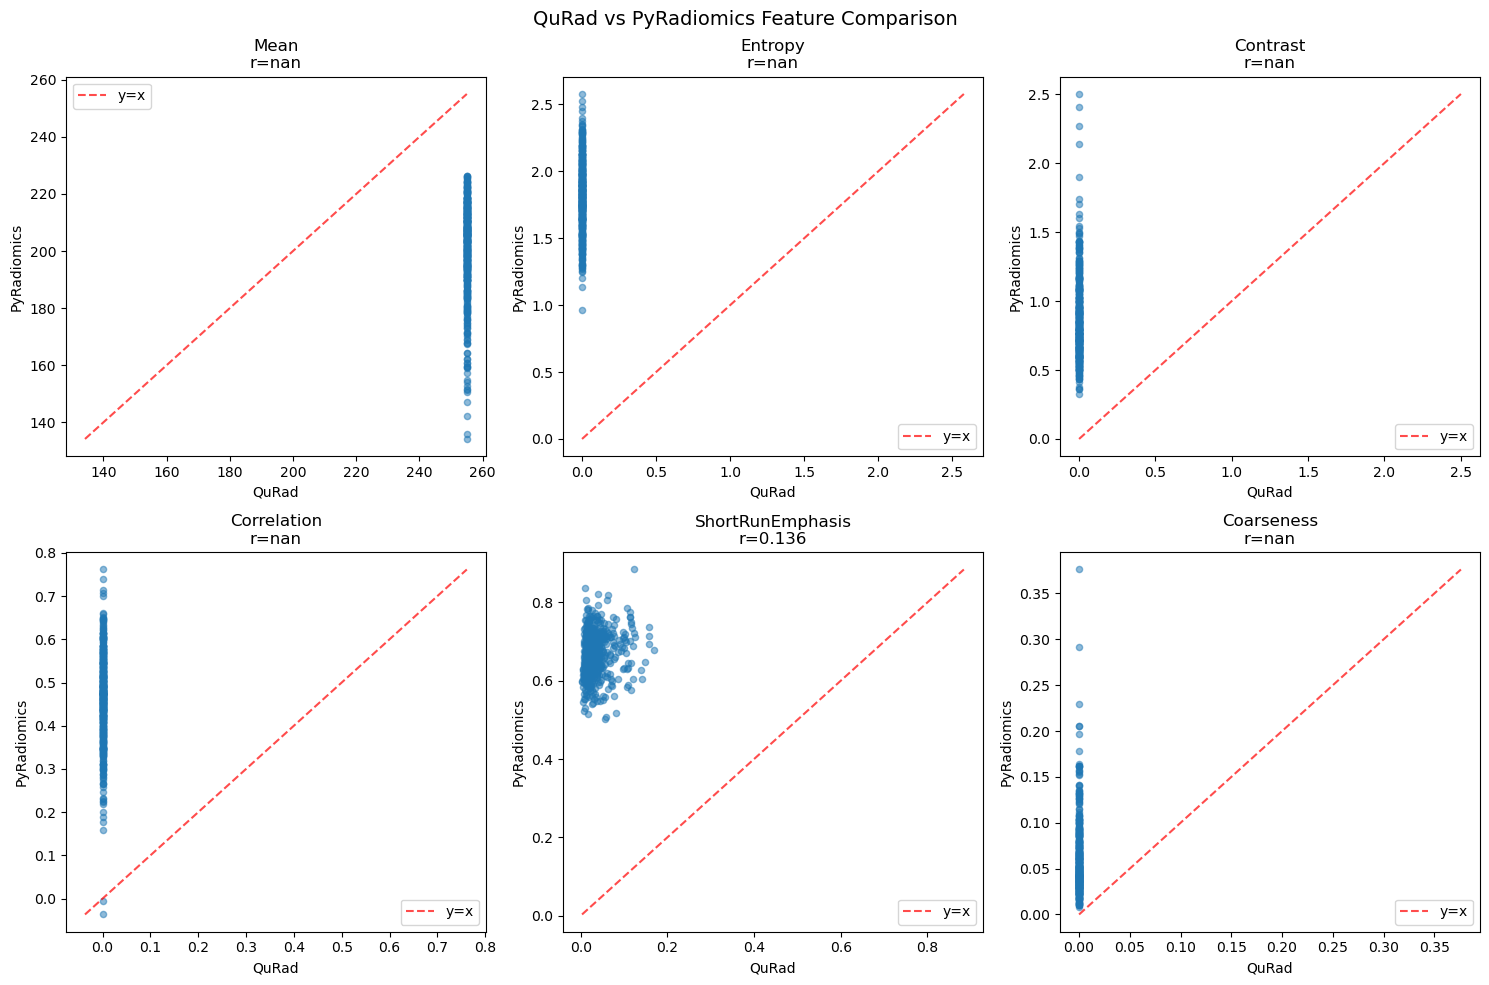


Plot saved to: /Users/tamara/Desktop/PyRadiomics/feature_comparison.png


In [13]:
import matplotlib.pyplot as plt

def plot_feature_comparison(qurad_df, pyrad_df, feature_mapping=None, n_compare=None):
    """Plot scatter plots comparing QuRad vs PyRadiomics for key features."""
    
    if n_compare is None:
        n_compare = min(len(qurad_df), len(pyrad_df))
    
    # Select key features to plot
    features_to_plot = [
        ('firstorder_Mean', 'original_firstorder_Mean'),
        ('firstorder_Entropy', 'original_firstorder_Entropy'),
        ('glcm_Contrast', 'original_glcm_Contrast'),
        ('glcm_Correlation', 'original_glcm_Correlation'),
        ('glrlm_ShortRunEmphasis', 'original_glrlm_ShortRunEmphasis'),
        ('ngtdm_Coarseness', 'original_ngtdm_Coarseness'),
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (qurad_feat, pyrad_feat) in enumerate(features_to_plot):
        if qurad_feat in qurad_df.columns and pyrad_feat in pyrad_df.columns:
            ax = axes[idx]
            
            x = qurad_df[qurad_feat].head(n_compare).values
            y = pyrad_df[pyrad_feat].head(n_compare).values
            
            ax.scatter(x, y, alpha=0.5, s=20)
            
            # Add diagonal line
            min_val = min(x.min(), y.min())
            max_val = max(x.max(), y.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='y=x')
            
            # Calculate correlation
            corr = np.corrcoef(x, y)[0, 1]
            
            ax.set_xlabel('QuRad')
            ax.set_ylabel('PyRadiomics')
            feature_name = qurad_feat.split('_', 1)[1]  # Remove prefix
            ax.set_title(f'{feature_name}\nr={corr:.3f}')
            ax.legend()
    
    plt.suptitle('QuRad vs PyRadiomics Feature Comparison', fontsize=14)
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'feature_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nPlot saved to: {BASE_DIR / 'feature_comparison.png'}")

# Run visualization
if 'qurad_df' in dir() and 'pyrad_df' in dir() and len(pyrad_results) > 0:
    # Use feature_mapping if available from comparison
    mapping = feature_mapping if 'feature_mapping' in dir() else None
    plot_feature_comparison(qurad_df, pyrad_df, feature_mapping=mapping)
else:
    print("Please run all previous cells first.")

## Summary & Interpretation

### Expected Differences

Some differences between QuRad and PyRadiomics are expected due to:

1. **Gray level quantization**: Different bin boundary handling
2. **GLCM directions**: QuRad uses 4 directions, PyRadiomics may use different defaults
3. **Shape calculations**: Different algorithms for perimeter/area
4. **Floating point precision**: Minor rounding differences

### Interpreting Results

- **Correlation > 0.95**: Excellent agreement
- **Correlation 0.8-0.95**: Good agreement (implementation differences)
- **Correlation < 0.8**: May indicate algorithmic differences worth investigating

In [14]:
# Save comparison results
if 'comparison_df' in dir() and comparison_df is not None and len(comparison_df) > 0:
    output_path = BASE_DIR / 'feature_comparison_results.csv'
    comparison_df.to_csv(output_path, index=False)
    print(f"Comparison results saved to: {output_path}")
    
    # Summary statistics
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"Features compared: {len(comparison_df)}")
    print(f"Mean correlation: {comparison_df['correlation'].mean():.4f}")
    print(f"Median correlation: {comparison_df['correlation'].median():.4f}")
    print(f"\nFeatures with correlation > 0.95: {(comparison_df['correlation'] > 0.95).sum()}")
    print(f"Features with correlation 0.8-0.95: {((comparison_df['correlation'] >= 0.8) & (comparison_df['correlation'] <= 0.95)).sum()}")
    print(f"Features with correlation < 0.80: {(comparison_df['correlation'] < 0.80).sum()}")
    
    # Show features with lowest correlation
    if (comparison_df['correlation'] < 0.95).any():
        print("\nFeatures with lowest correlation:")
        display(comparison_df.nsmallest(5, 'correlation')[['feature', 'correlation', 'rel_diff_pct']])

Comparison results saved to: /Users/tamara/Desktop/PyRadiomics/feature_comparison_results.csv

SUMMARY
Features compared: 99
Mean correlation: 0.1425
Median correlation: 0.0000

Features with correlation > 0.95: 1
Features with correlation 0.8-0.95: 7
Features with correlation < 0.80: 91

Features with lowest correlation:


,feature,correlation,rel_diff_pct
41,gldm_DependenceEntropy,-0.399292,59.430664
43,gldm_DependenceNonUniformityNormalized,-0.318184,163.510524
50,gldm_LargeDependenceLowGrayLevelEmphasis,-0.279844,70.125469
44,gldm_DependenceVariance,-0.227117,33.092546
61,glrlm_LongRunLowGrayLevelEmphasis,-0.214297,238.766189


## Features Missing in PyRadiomics

List all features that are in QuRad but not available in PyRadiomics.


In [15]:
# Display features only in QuRad (missing in PyRadiomics)
if 'qurad_only' in dir() and len(qurad_only) > 0:
    print(f"Features only in QuRad (missing in PyRadiomics): {len(qurad_only)}\n")
    print("=" * 80)
    
    # Group by feature class
    missing_by_class = {}
    for feat in sorted(qurad_only):
        parts = feat.split('_', 1)
        if len(parts) == 2:
            cls = parts[0]
            if cls not in missing_by_class:
                missing_by_class[cls] = []
            missing_by_class[cls].append(parts[1])
    
    # Display grouped by class
    for cls in sorted(missing_by_class.keys()):
        print(f"\n{cls.upper()} ({len(missing_by_class[cls])} features):")
        for feat_name in sorted(missing_by_class[cls]):
            print(f"  - {cls}_{feat_name}")
    
    print(f"\n" + "=" * 80)
    print(f"Total missing features: {len(qurad_only)}")
    print(f"\nNote: QuRad has {len(qurad_feat_cols) if 'qurad_feat_cols' in dir() else 'N/A'} total features")
    print(f"      PyRadiomics has {len(pyrad_feat_cols) if 'pyrad_feat_cols' in dir() else 'N/A'} total features")
else:
    print("Run the comparison cell (Cell 15) first to identify missing features.")


Features only in QuRad (missing in PyRadiomics): 21


FIRSTORDER (1 features):
  - firstorder_StandardDeviation

GLDM (1 features):
  - gldm_DependencePercentage

SHAPE (16 features):
  - shape_Compactness1
  - shape_Compactness2
  - shape_Elongation
  - shape_LeastAxisLength
  - shape_MajorAxisLength
  - shape_Maximum2DDiameterColumn
  - shape_Maximum2DDiameterRow
  - shape_Maximum2DDiameterSlice
  - shape_Maximum3DDiameter
  - shape_MeshVolume
  - shape_MinorAxisLength
  - shape_SphericalDisproportion
  - shape_Sphericity
  - shape_SurfaceArea
  - shape_SurfaceVolumeRatio
  - shape_VoxelVolume

SHAPE2D (3 features):
  - shape2D_Flatness
  - shape2D_MeshSurfaceArea
  - shape2D_SphericalDisproportion

Total missing features: 21

Note: QuRad has 120 total features
      PyRadiomics has 104 total features
